In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns

In [16]:
df = pd.read_csv('D:\ML\Regression\economic_index.csv')

In [17]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [18]:
df.drop(columns = ['Unnamed: 0','year', 'month'], axis= 1, inplace=True)

In [19]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [20]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

Text(0, 0.5, 'Unemployment rate')

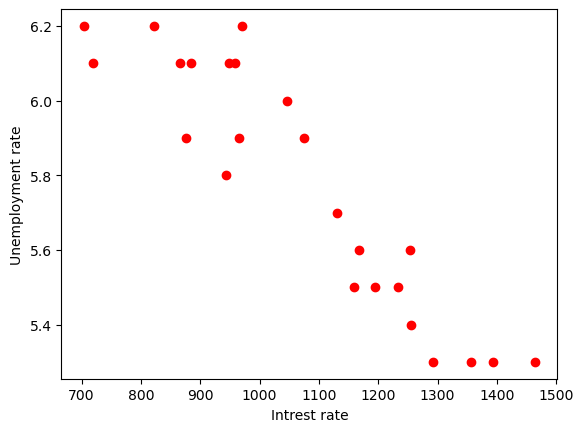

In [21]:
plt.scatter(df['index_price'], df['unemployment_rate'], color= 'r' )
plt.xlabel('Intrest rate')
plt.ylabel('Unemployment rate')

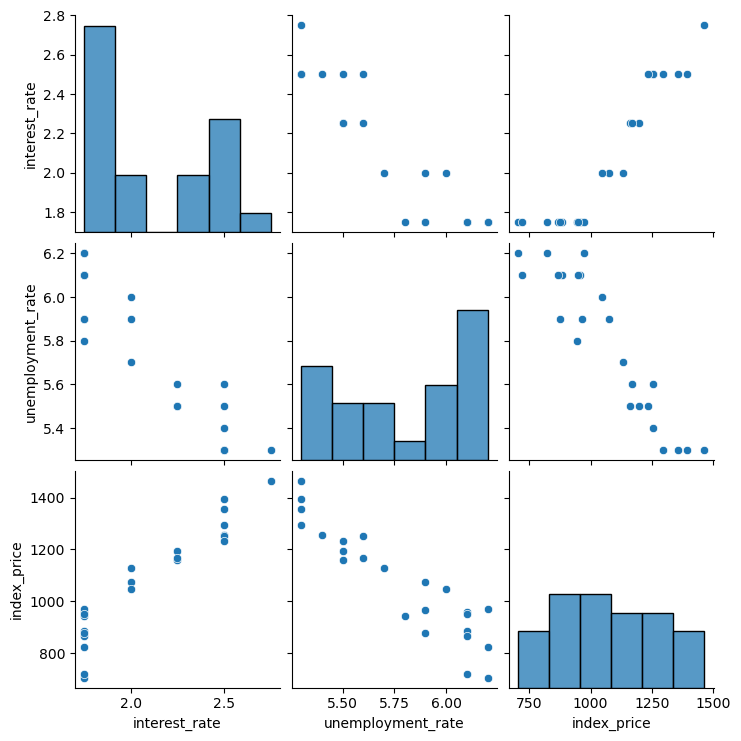

In [23]:
sns.pairplot(df)

In [24]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


In [ ]:
# Get my independent and dependent feature

x = df.iloc[:, :-1] ## this means from staring select all the features, except last feature
y = df.iloc[:,-1]

In [26]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [27]:
# Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y , test_size= 0.25, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

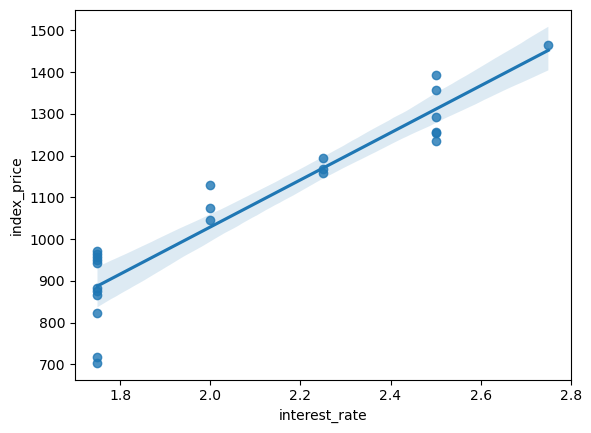

In [38]:
sns.regplot(x=df['interest_rate'], y=df['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

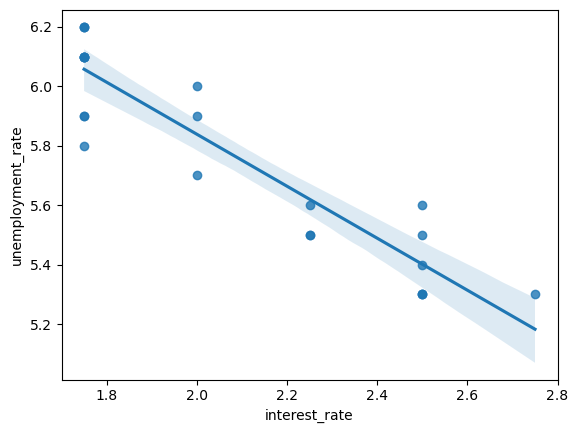

In [39]:
sns.regplot(x=df['interest_rate'], y=df['unemployment_rate'])

In [41]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [42]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### cross_val_score()

Evaluates a score by cross-validation

In [46]:
# Cross validartion

from sklearn.model_selection import cross_val_score

validation_score = cross_val_score(regression, x_train, y_train, 
                                   scoring='neg_mean_squared_error', cv= 3)


In [45]:
np.mean(validation_score)

np.float64(-5914.828180162392)

In [47]:
# prediction 
y_pred = regression.predict(x_test)

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse= mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

8108.567426306604
73.80444932337097
90.04758423359621


In [55]:
from sklearn.metrics import r2_score

r_sq = r2_score(y_test, y_pred)
print(r_sq)

0.7591371539010257


### Assumptions 


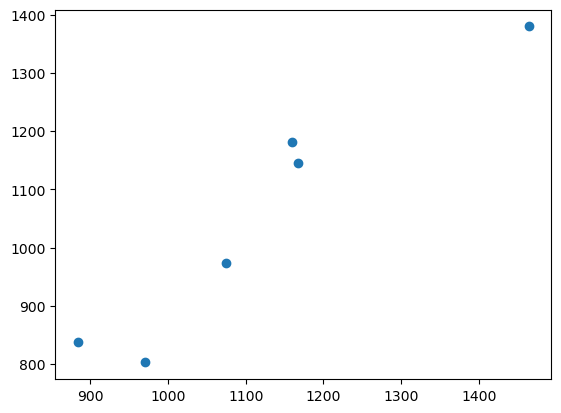

In [56]:
plt.scatter(y_test, y_pred)

In [58]:
residuales = y_test- y_pred
print(residuales)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


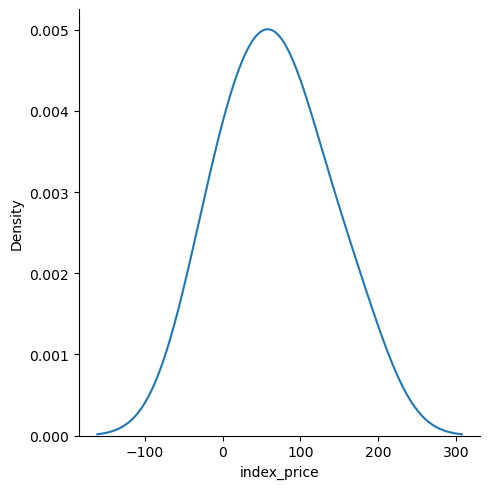

In [59]:
## plot this residuals
sns.displot(residuales, kind='kde')

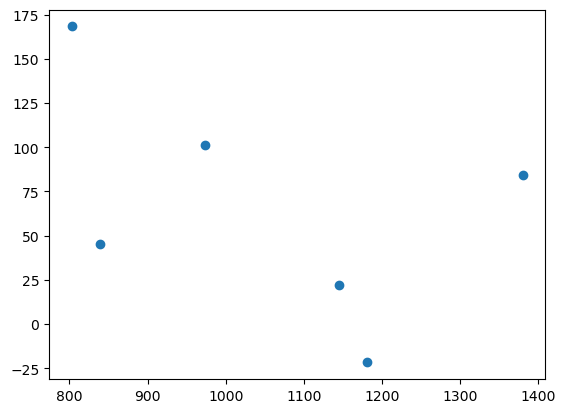

In [60]:
## scatter plot wrt prediction and residuals 

plt.scatter(y_pred, residuales)

This plot is in uniform distribution so our model is good

In [61]:
import statsmodels.formula.api as smf


In [62]:
model = smf.ols('y~x', data= df).fit()

In [63]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     92.07
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           4.04e-11
Time:                        22:11:38   Log-Likelihood:                -134.61
No. Observations:                  24   AIC:                             275.2
Df Residuals:                      21   BIC:                             278.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1798.4040    899.248      2.000      0.059     -71.685    3668.493
x[0]         345.5401    111.367      3.103      0.005     113.940     577.140
x[1]        -250.1466    117.950     -2.121      0.046    -495.437      -4.856
==============================================================================
Omnibus:                        2.691   Durbin-Watson:                   0.530
Prob(Omnibus):                  0.260   Jarque-Bera (JB):                1.551
Skew:                          -0.612   Prob(JB):                        0.461
Kurtosis:                       3.226   Cond. No.                         394.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""